# 1: Дослідження динаміки популяції

Модель росту популяції описується диференціальним рівнянням:
$$\frac{dN}{dt} = \beta \frac{N^2}{1 + N} - \delta N - p N^2$$

Де:
* $\beta = 36$ — коефіцієнт народжуваності;
* $\delta = 15$ — коефіцієнт смертності;
* $p = 3$ — коефіцієнт внутрішньовидової конкуренції.

In [19]:
beta = 36
delta = 15
p = 3

### Знаходження точок рівноваги

Для визначення стаціонарних станів популяції необхідно розв'язати рівняння $\frac{dN}{dt} = 0$:

$$\beta \frac{N^2}{1 + N} - \delta N - p N^2 = 0$$

$$N \left( \frac{\beta N}{1 + N} - \delta - p N \right) = 0$$

Звідси перший корінь **$N_0 = 0$**.
Прирівняємо вираз у дужках до нуля:

$$\frac{\beta N}{1 + N} - \delta - p N = 0$$

Помножимо рівняння на $(1 + N)$:

$$\beta N - \delta(1 + N) - p N(1 + N) = 0$$
$$\beta N - \delta - \delta N - p N - p N^2 = 0$$
$$-p N^2 + (\beta - \delta - p)N - \delta = 0$$

Підставимо $\beta, \delta, p$:

$$-3 N^2 + (36 - 15 - 3)N - 15 = 0$$
$$-3 N^2 + 18 N - 15 = 0$$
$$N^2 - 6N + 5 = 0$$

Корені:
* $N_1 = 1$ - нижня критична межа
* $N_2 = 5$ - верхня критична межа

In [20]:
import numpy as np
coeffs = [p, -(beta - delta - p), delta]
roots = np.roots(coeffs)
N_low = min(roots)
N_high = max(roots)

print(f"Нижня критична межа (N1): {N_low}")
print(f"Верхня критична межа (N2): {N_high}")

Нижня критична межа (N1): 1.0
Верхня критична межа (N2): 5.0


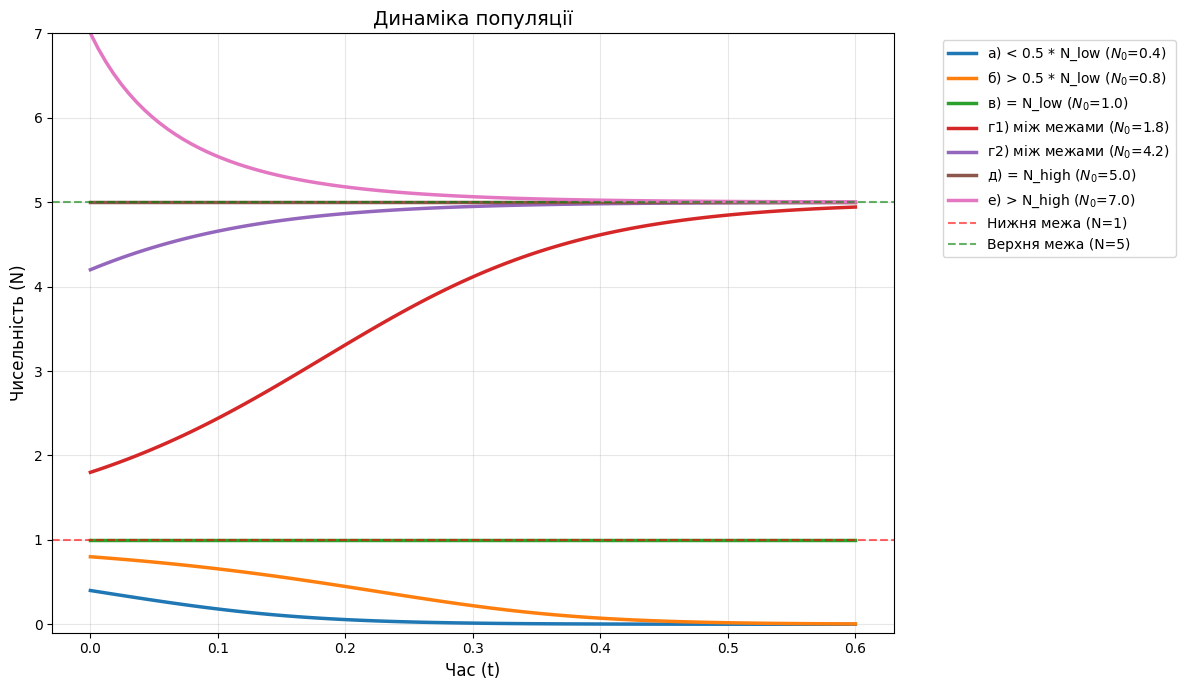

In [21]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def model(N, t):
    return beta * (N**2 / (1 + N)) - delta * N - p * (N**2)

diff = N_high - N_low
n0_values = {
    "а) < 0.5 * N_low": 0.4,
    "б) > 0.5 * N_low": 0.8,
    "в) = N_low": 1.0,
    "г1) між межами": N_low + 0.2 * diff,
    "г2) між межами": N_low + 0.8 * diff,
    "д) = N_high": 5.0,
    "е) > N_high": 7.0
}

t = np.linspace(0, 0.6, 100) 

plt.figure(figsize=(12, 7))

all_solutions = []

for label, n0 in n0_values.items():
    sol = odeint(model, n0, t)
    plt.plot(t, sol, label=f"{label} ($N_0$={n0})", linewidth=2.5)
    all_solutions.append(sol)

plt.axhline(N_low, color='red', linestyle='--', alpha=0.6, label='Нижня межа (N=1)')
plt.axhline(N_high, color='green', linestyle='--', alpha=0.6, label='Верхня межа (N=5)')

plt.title("Динаміка популяції", fontsize=14)
plt.xlabel("Час (t)", fontsize=12)
plt.ylabel("Чисельність (N)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

plt.ylim(-0.1, 7.0) 

plt.tight_layout()
plt.show()

# 2: Моделювання популяції риб у ставку

Рівняння динаміки чисельності риб $N(t)$:
$$\dot{N} = -0.008N^2 + 1.6N$$

У логістичному вигляді:
$$\frac{dN}{dt} = rN \left(1 - \frac{N}{K}\right)$$

Загальний розв'язок:
$$N(t) = \frac{K}{1 + (\frac{K - N_0}{N_0}) e^{-rt}}$$

Де:
* $r = 1.6$ — питома швидкість росту;
* $K = 1.6 / 0.008 = 200$ — ємність середовища (максимальна чисельність);
* $N_0$ — початкова чисельність риб.

In [27]:
r = 1.6
K = 200
t_target = 30

def logistic_solution(t, N0, r, K):
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

N_t30_case1 = logistic_solution(t_target, 30, r, K)
N_t30_case2 = logistic_solution(t_target, 400, r, K)

print(f"При N0 = 30, через 30 місяців чисельність: {N_t30_case1:.1f}")
print(f"При N0 = 400, через 30 місяців чисельність: {N_t30_case2:.1f}")

При N0 = 30, через 30 місяців чисельність: 200.0
При N0 = 400, через 30 місяців чисельність: 200.0


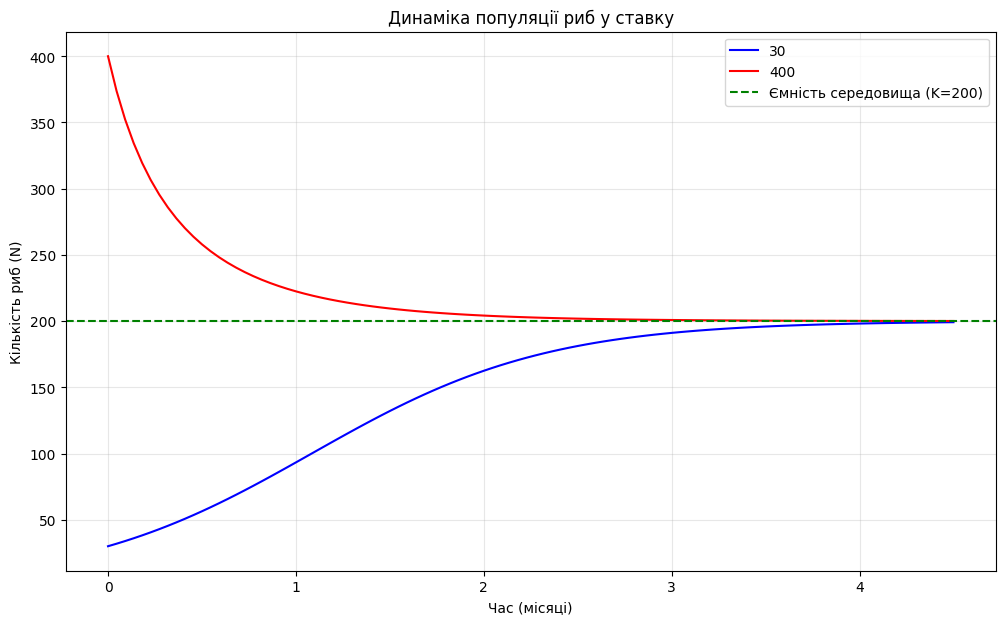

In [34]:
t_axis = np.linspace(0, 4.5, 100)

plt.figure(figsize=(12, 7))

plt.plot(t_axis, logistic_solution(t_axis, 30, r, K), 'b-', label='30')
plt.plot(t_axis, logistic_solution(t_axis, 400, r, K), 'r-', label='400')

plt.axhline(K, color='green', linestyle='--', label=f'Ємність середовища (K={K})')

plt.title("Динаміка популяції риб у ставку")
plt.xlabel("Час (місяці)")
plt.ylabel("Кількість риб (N)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Тип популяції - обмежена. 

# Модель конкурентних видів (Лоткі - Вольтерри)

Система диференціальних рівнянь описує взаємодію двох видів, що конкурують за спільний ресурс:
$$
\begin{cases} 
\frac{dN_1}{dt} = a_1 N_1 - b_{12} N_1 N_2 - c_1 N_1^2 \\
\frac{dN_2}{dt} = a_2 N_2 - b_{21} N_1 N_2 - c_2 N_2^2 
\end{cases}
$$

Де:
* $a_i$ — швидкість природного росту;
* $c_i$ — коефіцієнт внутрішньовидової конкуренції (обмеження ємності середовища);
* $b_{ij}$ — коефіцієнт міжвидової конкуренції.

Для того, щоб два види могли стабільно співіснувати в одній екосистемі, необхідно, щоб точка перетину ізоклін лежaла в межах позитивного квадранта і була стійким вузлом. Це означає, що:
$$c_1 \cdot c_2 > b_{12} \cdot b_{21}$$
Тобто кожен вид повинен обмежувати свій власний ріст сильніше, ніж ріст конкурента.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

a1, a2 = 1.2, 1.0     # Коефіцієнти росту
c1, c2 = 0.6, 0.5     # Сильна внутрішньовидова конкуренція (K1=2, K2=2)
b12, b21 = 0.2, 0.1   # Слабка міжвидова конкуренція

# 2. Знаходження нетривіальної точки рівноваги (N1 > 0, N2 > 0)
# Розв'язуємо систему лінійних рівнянь:
# c1*N1 + b12*N2 = a1
# b21*N1 + c2*N2 = a2
A = np.array([[c1, b12], [b21, c2]])
B = np.array([a1, a2])
eq_point = np.linalg.solve(A, B)

# Інші точки спокою:
points = [
    (0, 0),             # Вимирання обох
    (a1/c1, 0),         # Тільки перший вид
    (0, a2/c2),         # Тільки другий вид
    (eq_point[0], eq_point[1]) # Співіснування
]

print(f"Точка стабільного співіснування: N1 = {eq_point[0]:.2f}, N2 = {eq_point[1]:.2f}")

Точка стабільного співіснування: N1 = 1.43, N2 = 1.71


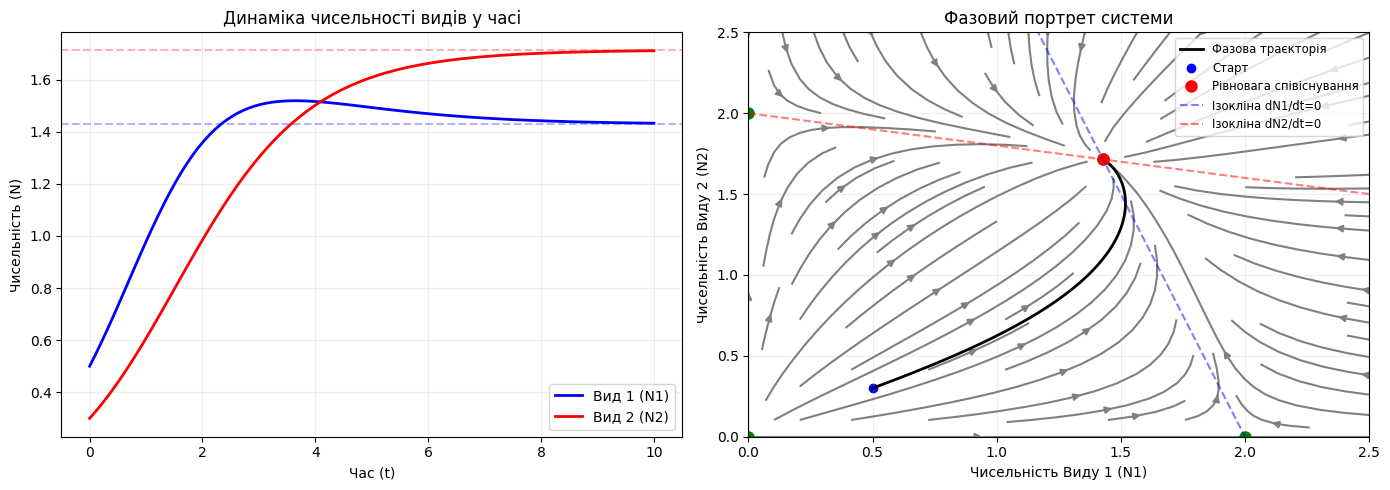

In [42]:
def competition_model(N, t):
    n1, n2 = N
    dn1 = a1*n1 - b12*n1*n2 - c1*n1**2
    dn2 = a2*n2 - b21*n1*n2 - c2*n2**2
    return [dn1, dn2]

t = np.linspace(0, 10, 100)
n0 = [0.5, 0.3] # Початкові значення
sol = odeint(competition_model, n0, t)

# Динаміка чисельності
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(t, sol[:, 0], 'b-', label='Вид 1 (N1)', linewidth=2)
plt.plot(t, sol[:, 1], 'r-', label='Вид 2 (N2)', linewidth=2)
plt.axhline(eq_point[0], color='b', linestyle='--', alpha=0.3)
plt.axhline(eq_point[1], color='r', linestyle='--', alpha=0.3)
plt.title("Динаміка чисельності видів у часі")
plt.xlabel("Час (t)")
plt.ylabel("Чисельність (N)")
plt.legend()
plt.grid(alpha=0.2)

# Фазовий портрет
plt.subplot(1, 2, 2)

# Векторне поле
x_range = np.linspace(0, 3, 20)
y_range = np.linspace(0, 3, 20)
X, Y = np.meshgrid(x_range, y_range)
U = a1*X - b12*X*Y - c1*X**2
V = a2*Y - b21*X*Y - c2*Y**2
plt.streamplot(X, Y, U, V, color='gray')

# Траєкторія
plt.plot(sol[:, 0], sol[:, 1], 'k-', label='Фазова траєкторія', linewidth=2)
plt.scatter(n0[0], n0[1], color='blue', label='Старт')

# Точки спокою
for p in points:
    plt.plot(p[0], p[1], 'go', markersize=8)
plt.plot(eq_point[0], eq_point[1], 'ro', markersize=8, label='Рівновага співіснування')

# Ізокліни
n1_iso = np.linspace(0, 3, 100)
plt.plot(n1_iso, (a1 - c1*n1_iso)/b12, 'b--', alpha=0.5, label='Ізокліна dN1/dt=0')
plt.plot(n1_iso, (a2 - b21*n1_iso)/c2, 'r--', alpha=0.5, label='Ізокліна dN2/dt=0')

plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.title("Фазовий портрет системи")
plt.xlabel("Чисельність Виду 1 (N1)")
plt.ylabel("Чисельність Виду 2 (N2)")
plt.legend(fontsize='small')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

1. Обрані параметри:  $c_1=0.6, c_2=0.5$ та $b_{12}=0.2, b_{21}=0.1$. Оскільки $c_1 c_2 (0.3) > b_{12} b_{21} (0.02)$, виконується умова стабільного співіснування.
2. Точки спокою:
   * (0, 0): Нестійкий вузол (джерело).
   * (2, 0) та (0, 2): Сідлові точки.
   * (1.6, 1.2) (приблизно): Стійкий вузол.